# Two-Dimensional Burgers' Equation

In [1]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
import random
import torch
import itertools
from scipy.interpolate import griddata
import scipy
import os
from scipy.stats import pearsonr
import matplotlib.ticker as mticker

## DeepONet Class and RK4 Time-stepping

In [2]:
class BranchNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        
        # #x has shape (ns, nx, ny) - so add channel dimension: (ns, nx, ny, nc)
        x = x[..., jnp.newaxis]

        #2D Convolutional layers and pooling layers
        x = nn.Conv(features = 64, kernel_size = (3,3), strides = (1,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2,2), strides = (2,2), padding = "SAME")

        x = nn.Conv(features = 64, kernel_size = (2,2), strides = (1,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape = (2,2), strides = (2,2), padding = "SAME")

        x = x.flatten()   #flattening layer
        for feat in self.features[:-1]:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.features[-1])(x)
        return x

class TrunkNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        for feat in self.features:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        return x

class DeepONet(nn.Module):
    branch_features: list
    trunk_features: list
    
    def setup(self):
        self.branch_net = BranchNet(self.branch_features)
        self.trunk_net = TrunkNet(self.trunk_features)

    @nn.compact
    def __call__(self, branch_input, trunk_input):
        branch_out = jax.vmap(self.branch_net, in_axes = 0)(branch_input) 
        trunk_out = jax.vmap(self.trunk_net, in_axes = 0)(trunk_input)     
        output = jnp.einsum('bi,ti->bt', branch_out, trunk_out) 
        bias = self.param('bias', nn.initializers.zeros, (1,))
        output = output + bias
        return output

In [3]:
# 4th order Runge-Kutta method
@jax.jit
def RK4(params,branch_x,trunk_x,dt = 0.01):
    
    curr_state = branch_x
    k1 = model.apply(params,curr_state,trunk_x)
    k1 = k1.reshape(k1.shape[0],nx,ny)
    k2 = model.apply(params,curr_state+0.5*dt*k1,trunk_x)
    k2 = k2.reshape(k2.shape[0],nx,ny)
    k3 = model.apply(params,curr_state+0.5*dt*k2,trunk_x)
    k3 = k3.reshape(k3.shape[0],nx,ny)
    k4 = model.apply(params,curr_state+dt*k3,trunk_x)
    k4 = k4.reshape(k4.shape[0],nx,ny)
    next_state = curr_state+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state.reshape(next_state.shape[0],nx*ny)
    return next_state

In [27]:
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)
model_fn = jax.jit(model.apply)

## Data Preparation

In [ ]:
dataset_burger = torch.load("/home/dnayak2/data_sgoswam4/Dibya/Datasets/2D_Burgers/Burgers_equation_2D_scalar.pt")
outputs = dataset_burger['output_samples'] 
outputs = jnp.array(outputs)
outputs = outputs[:1200]
del dataset_burger
n_samples = outputs.shape[0]
nx = outputs.shape[2]
ny = outputs.shape[3]
nt = outputs.shape[1]
param_path = "ti_don_2d_burger.pkl" 

xspan = jnp.linspace(0, 1, nx)
yspan = jnp.linspace(0, 1, ny)
[x,y] = jnp.meshgrid(xspan, yspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([x.flatten(), y.flatten()]))
x = jnp.linspace(0,1,nx)
y = jnp.linspace(0,1,ny)
t = jnp.linspace(0,1,nt)
data_test = outputs
del outputs

with open(param_path, "rb") as f:
    params = pickle.load(f)


In [29]:
folder = "/home/rroy13/jax.venv/DeepONet/Coupling2D/2D_Burger"
os.makedirs(folder, exist_ok=True)

## Residual and Error Estimator

In [ ]:
## EMA-based error Estimator
@jax.jit
def burgers2d_res_error(params,u_curr, x,y,grid,eta_hist, nu=0.01): # u_curr -> branch input, #coll_points -> trunk input
    
    #print(u_curr.shape)
    u_curr_t = model.apply(params,u_curr, grid) 
    u_curr_t = u_curr_t[0].reshape(x.shape[0],y.shape[0])
    u_curr = u_curr[0]
    u = u_curr
    u_t = u_curr_t
    u_x = jnp.gradient(u,x,axis = 0)
    u_y = jnp.gradient(u,y,axis = 1)
    
    u_xx = jnp.gradient(u_x,x,axis = 0)
    u_yy = jnp.gradient(u_y,y,axis = 1)
    res = u_t + u*(u_x+u_y) - nu*(u_xx+u_yy)
    alpha = 0.02
    r = jnp.linalg.norm(res)/jnp.linalg.norm(u_curr)
    eta = alpha*r+(1-alpha)*eta_hist
    
    return res,eta

## Numerical Solver

In [31]:
def initialize_burgers_2d(xmin=0, xmax=1, ymin=0, ymax=1, Nx=100, Ny=100, 
                         nu=0.01, dt=1e-3, tend=1.0):
    """Initialize 2D Burgers equation parameters and grid"""
    x = np.linspace(xmin, xmax, Nx)
    y = np.linspace(ymin, ymax, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    params = {
        'xmin': xmin, 'xmax': xmax, 'ymin': ymin, 'ymax': ymax,
        'Nx': Nx, 'Ny': Ny, 'x': x, 'y': y, 'dx': dx, 'dy': dy,
        'X': X, 'Y': Y, 'nu': nu, 'dt': dt, 'tend': tend
    }
    
    return params

# All Central Differencing Functions are 4th order - matching original implementation
def CD_i(data, axis, dx):
    """4th order central difference for first derivative"""
    # Handle batch dimension properly
    if data.ndim == 3:  # (nsamples, nx, ny)
        if axis == 0:  # x-direction
            axis_to_roll = 1
        else:  # y-direction (axis == 1)
            axis_to_roll = 2
    else:  # (nx, ny)
        axis_to_roll = axis
    
    data_m2 = np.roll(data, 2, axis=axis_to_roll)
    data_m1 = np.roll(data, 1, axis=axis_to_roll)
    data_p1 = np.roll(data, -1, axis=axis_to_roll)
    data_p2 = np.roll(data, -2, axis=axis_to_roll)
    data_diff_i = (data_m2 - 8.0*data_m1 + 8.0*data_p1 - data_p2)/(12.0*dx)
    return data_diff_i

def CD_ij(data, axis_i, axis_j, dx, dy):
    """4th order central difference for mixed second derivative"""
    data_diff_i = CD_i(data, axis_i, dx)
    data_diff_ij = CD_i(data_diff_i, axis_j, dy)
    return data_diff_ij

def CD_ii(data, axis, dx):
    """4th order central difference for second derivative"""
    # Handle batch dimension properly
    if data.ndim == 3:  # (nsamples, nx, ny)
        if axis == 0:  # x-direction
            axis_to_roll = 1
        else:  # y-direction (axis == 1)
            axis_to_roll = 2
    else:  # (nx, ny)
        axis_to_roll = axis
    
    data_m2 = np.roll(data, 2, axis=axis_to_roll)
    data_m1 = np.roll(data, 1, axis=axis_to_roll)
    data_p1 = np.roll(data, -1, axis=axis_to_roll)
    data_p2 = np.roll(data, -2, axis=axis_to_roll)
    data_diff_ii = (-data_m2 + 16.0*data_m1 - 30.0*data + 16.0*data_p1 - data_p2)/(12.0*dx**2)
    return data_diff_ii

def Dx(data, dx):
    """First derivative with respect to x"""
    return CD_i(data=data, axis=0, dx=dx)

def Dy(data, dy):
    """First derivative with respect to y"""
    return CD_i(data=data, axis=1, dx=dy)

def Dxx(data, dx):
    """Second derivative with respect to x"""
    return CD_ii(data, axis=0, dx=dx)

def Dyy(data, dy):
    """Second derivative with respect to y"""
    return CD_ii(data, axis=1, dx=dy)

def burgers_calc_RHS(u, params):
    """Calculate right-hand side of 2D Burgers equation"""
    u_xx = Dxx(u, params['dx'])
    u_yy = Dyy(u, params['dy'])
    u2 = u**2.0
    u2_x = Dx(u2, params['dx'])
    u2_y = Dy(u2, params['dy'])
    u_RHS = -0.5*(u2_x + u2_y) + params['nu']*(u_xx + u_yy)
    return u_RHS

def update_field(field, RHS, dt, step_frac):
    """Update field for RK4 intermediate steps"""
    field_new = field + dt*step_frac*RHS
    return field_new

def rk4_merge_RHS(field, RHS1, RHS2, RHS3, RHS4, dt):
    """Merge RK4 stages for final update"""
    field_new = field + dt/6.0*(RHS1 + 2*RHS2 + 2.0*RHS3 + RHS4)
    return field_new

def burgers_rk4(u, t, params):
    """4th order Runge-Kutta time integration for 2D Burgers equation"""
    dt = params['dt']
    
    u_RHS1 = burgers_calc_RHS(u, params)
    u1 = update_field(u, u_RHS1, dt, step_frac=0.5)
    
    u_RHS2 = burgers_calc_RHS(u1, params)
    u2 = update_field(u, u_RHS2, dt, step_frac=0.5)
    
    u_RHS3 = burgers_calc_RHS(u2, params)
    u3 = update_field(u, u_RHS3, dt, step_frac=1.0)
    
    u_RHS4 = burgers_calc_RHS(u3, params)
    
    t_new = t + dt
    u_new = rk4_merge_RHS(u, u_RHS1, u_RHS2, u_RHS3, u_RHS4, dt)
    
    return u_new, t_new

def burgers_driver_batch(u0_batch, save_timestamps, params):
    """
    Main driver function for batch 2D Burgers equation simulation
    
    Args:
        u0_batch: Initial conditions with shape (nsamples, nx, ny)
        save_timestamps: Array of timestamps to save solutions
        params: Dictionary of simulation parameters
    
    Returns:
        T: Array of timestamps (nt,)
        X, Y: Coordinate meshgrids (nx, ny)
        U: Solution array with shape (nsamples, nt, nx, ny)
    """
    nsamples, Nx, Ny = u0_batch.shape
    tend = params['tend']
    
    # Ensure grid dimensions match
    assert Nx == params['Nx'], f"Grid size mismatch: input Nx={Nx}, params Nx={params['Nx']}"
    assert Ny == params['Ny'], f"Grid size mismatch: input Ny={Ny}, params Ny={params['Ny']}"
    
    # Initialize arrays
    nt = len(save_timestamps)
    U_batch = np.zeros((nsamples, nt, Nx, Ny))
    T = []
    
    # Store initial conditions at t=0 (first timestep)
    U_batch[:, 0, :, :] = u0_batch.copy()
    T.append(0.0)
    
    # Current state for all samples
    u_current = u0_batch.copy()
    t = 0.0
    save_index = 1  # Start from 1 since we already saved initial condition
    
    # Time integration loop - match original logic
    while t <= tend and save_index < nt:
        u_current, t = burgers_rk4(u_current, t, params)
        
        # Check if we need to save at this timestamp
        if save_index < len(save_timestamps) and np.isclose(t, save_timestamps[save_index], atol=1e-8):
            U_batch[:, save_index, :, :] = u_current.copy()
            T.append(t)
            save_index += 1
    
    return np.array(T), params['X'], params['Y'], U_batch

def burgers_solver(u0_batch, save_timestamps, **kwargs):
    """
    Convenience function to solve 2D Burgers equation for batch of initial conditions
    
    Args:
        u0_batch: Initial conditions with shape (nsamples, nx, ny)
        save_timestamps: Array of timestamps to save solutions
        **kwargs: Parameters for initialize_burgers_2d()
    
    Returns:
        T: Array of timestamps (nt,)
        X, Y: Coordinate meshgrids (nx, ny)  
        U: Solution array with shape (nsamples, nt, nx, ny)
    """
    nsamples, Nx, Ny = u0_batch.shape
    
    # Set default grid size based on input
    if 'Nx' not in kwargs:
        kwargs['Nx'] = Nx
    if 'Ny' not in kwargs:
        kwargs['Ny'] = Ny
        
    # Initialize parameters
    params = initialize_burgers_2d(**kwargs)
    
    # Run batch simulation
    return burgers_driver_batch(u0_batch, save_timestamps, params)

def plot_data(X, Y, u, cmap='jet', vmin=None, vmax=None, fig_num=0, 
              title='', xlabel='', ylabel=''):
    """Plot 2D data"""
    plt.figure(fig_num, figsize=(8, 6))
    plt.clf()
    
    c = plt.pcolormesh(X, Y, u, cmap=cmap, vmin=vmin, vmax=vmax, shading='gouraud')
    plt.colorbar(c)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


## Numerical Experimentation

### Correlation between EMA-based estimator and actual error

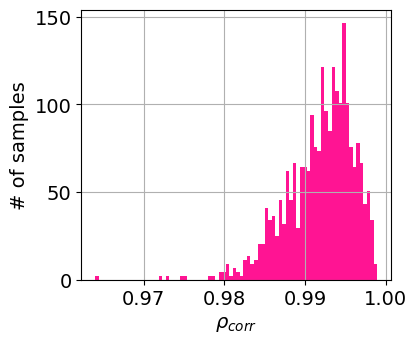

In [ ]:
## All Samples to compute pearson's coefficient
np.random.seed(50)
test_sample = np.random.choice(1000, size=1000, replace=False)
u_pred_model = np.zeros((len(test_sample),nt,nx,ny))
eta_list_final = np.zeros((len(test_sample),nt-1))
l2error_list_final = np.zeros((len(test_sample),nt))
for k,ns in enumerate(test_sample):
    u_test = data_test[ns:ns+1,:nt]
    branch_test = data_test[ns:ns+1,0]
    trunk_test = grid
    u_pred_model[k,0,:] = branch_test
    u_curr = branch_test
    eta = 0
    eta_list = []
    for i in range(1, nt):
        u_curr = RK4(params,u_curr,grid,dt = 0.01)
        u_curr = u_curr.reshape(-1,nx,ny)
        res,eta = burgers2d_res_error(params,u_curr,x,y,grid,eta)
        eta_list.append(eta)
        u_pred_model[k,i,:,:] = u_curr
        
    eta_list_final[k]=np.array(eta_list)
    l2_error = []
    for i in range(nt):
        l2_error.append(np.linalg.norm(u_pred_model[k,i] - u_test[0,i])/\
                         np.linalg.norm(u_test[0,i]))
    
    l2error_list_final[k] = np.array(l2_error)
    
    
r_list = [pearsonr(np.array(l2error_list_final[i,1:]),
                   np.array(eta_list_final[i]))[0] for i in range(len(test_sample))]
r_list = np.array(r_list)

plt.figure(figsize = (4,3.5))
plt.hist(r_list,density = True,bins = 80,color = 'deeppink')
# plt.title("Correlation between error estimator and actual error",fontsize = 14)
plt.xlabel(rf"$\rho_{{corr}}$",fontsize = 14)
plt.ylabel("# of samples",fontsize = 14)
plt.grid()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.01))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.savefig(folder+"/pearson_coeff.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
## Autoregressive Predictions
u_auto = np.load('u_pred_auto_2dburger.npz')['arr_0']

### Sample-by-sample study between AR-DON, TI-DON and ANCHOR (Ours)

In [53]:
# Visualize the sample
np.random.seed(40)
# test_sample = random.sample(range(0, 2500), 1)
test_sample = np.random.choice(1000, size=1, replace=False)

print(f"Sample chosen: {test_sample}")
u_pred_auto = u_auto[test_sample]                                                  
u_test = data_test[test_sample,:nt]
branch_test = data_test[test_sample,0]
trunk_test = grid

sample_folder = f"/sample_{test_sample[0]}"
os.makedirs(folder+sample_folder, exist_ok=True)

Sample chosen: [204]


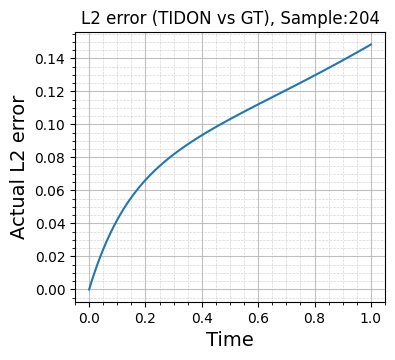

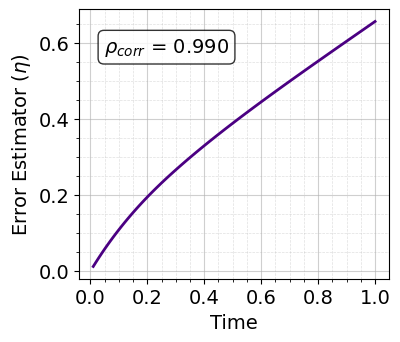

In [ ]:
u_pred_model = np.zeros((nt,nx,ny))
u_pred_model[0,:,:] = branch_test
u_curr = branch_test
eta = 0
eta_list = []
for i in range(1, nt):
    ti = t[i]
    u_curr = RK4(params,u_curr,grid,dt = 0.01)
    u_curr = u_curr.reshape(-1,nx,ny)
    res,eta = burgers2d_res_error(params,u_curr,x,y,grid,eta)
    eta_list.append(eta)
    u_pred_model[i,:,:] = u_curr

l2_error1 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i,:,:] - u_test[0,i,:,:])/np.linalg.norm(u_test[0,i,:,:]))

plt.figure(figsize =(4,3.5))
plt.plot(jnp.linspace(0,1,nt),jnp.array(l2_error1),label = 'TIDON')
#plt.plot(jnp.linspace(0,1,dim_t),jnp.array(l2_error2),label = 'NS')
plt.title(f"L2 error (TIDON vs GT), Sample:{test_sample[0]}")
plt.xlabel("Time",fontsize = 14)
plt.ylabel("Actual L2 error",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

# plt.savefig(folder+sample_folder+"/err_estm.png",dpi=300)
plt.show()

plt.figure(figsize =(4,3.5))
plt.plot(t[1:],np.array(eta_list),color = 'indigo',lw = 2)
# plt.title(f"EMA-based Error Estimator")#, Sample:{test_sample[0]}")
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Error Estimator ($\eta$)",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.text(0.08, 0.9, rf"$\rho_{{corr}}$ = {pearsonr(np.array(l2_error1[1:]),np.array(eta_list))[0]:.3f}",
    transform=plt.gca().transAxes,fontsize = 14,va='top',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.savefig(folder+sample_folder+"/err_estm.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
# Timing TI-DON
u_curr = branch_test
st = time.time()
for i in range(1, nt):
    # ti = t[i]
    u_curr = RK4(params,u_curr,grid,dt = 0.01)
    u_curr = u_curr.reshape(-1,nx,ny)
    u_pred_model[i,:,:] = u_curr
et = time.time()-st
print("TIDON Time: ",et)

TIDON Time:  0.1376039981842041


In [ ]:
## Timing Numerical Solver
save_timestamps = np.linspace(0,1,101)
st = time.time()
T, X, Y, u_solver = burgers_solver(branch_test, save_timestamps, Nx=32, Ny=32, nu=0.01, dt=1e-3, tend=1.0)
et = time.time()-st
print("Solver Time: ",et)

Solver Time:  7.928395986557007


In [ ]:
## ANCHOR Framework
mark_model = []
mark_coup = []

u_pred_coup= np.zeros((nt,nx,ny))
u_pred_coup[0,:,:] = branch_test
i = 1
u_curr = RK4(params,branch_test,trunk_test) #u_curr at i=1
u_curr = u_curr.reshape(-1,nx,ny)

mark_model.append(i)

eta_thres = 0

res,eta = burgers2d_res_error(params,branch_test,x,y,grid,eta_hist=0)
rnorm0 = np.linalg.norm(res)
print(rnorm0)
umax0 = np.max(branch_test)
print(umax0)

st = time.time()
while i<nt:
    ti = t[i]
    res,eta = burgers2d_res_error(params,u_curr,x,y,grid,eta) # computes residual at ith step using u_curr at ith step
    
    Kut = np.exp(-ti)*np.exp(-umax0)*umax0
    eta_thres = (Kut)

    print(f"estimator:{eta:.6f}|threshold:{eta_thres:.6f}")
    
    if eta<eta_thres:
        #print(i)
        #print(f"tidon {i}")
        u_pred_coup[i,:] = u_curr
        i+=1
        u_curr = RK4(params,u_curr,trunk_test)  # u_curr at i+1
        u_curr = u_curr.reshape(-1,nx,ny)
        mark_model.append(i)
    else:
        #i-=1
        print(f"ns {i}")
        
        #print(i)
        u_init = u_curr
        #u_init = u_pred_coup[i,:]
        dt = 0.01
        nsteps = 11
        save_timestamps = np.linspace(0,dt*(nsteps-1),nsteps)
        _, _, _, u_final = burgers_solver(u_init, save_timestamps, Nx=32, Ny=32, nu=0.01, dt=1e-3, tend=dt*(nsteps-1))
        if i+nsteps<nt:
            u_pred_coup[i:i+nsteps,:,:] = u_final[0]
        else:
            nsteps = nt-i
            u_pred_coup[i:i+nsteps,:,:] = u_final[0,:nsteps,:,:]
        mark_coup.append(list(range(i, i+nsteps)))
        i+=nsteps
        u_curr = u_pred_coup[i-1:i,:,:]#.reshape(1,dim_x)
        res,eta = burgers2d_res_error(params,u_curr,x,y,grid,eta_hist=0)
        u_curr = RK4(params,u_curr,trunk_test)
        u_curr = u_curr.reshape(-1,nx,ny)

et = time.time()
print("ANCHOR Time:",et-st)    

0.886215
0.16427237
estimator:0.024307|threshold:0.138000
estimator:0.035952|threshold:0.136627
estimator:0.047277|threshold:0.135267
estimator:0.058298|threshold:0.133921
estimator:0.069031|threshold:0.132589
estimator:0.079489|threshold:0.131270
estimator:0.089683|threshold:0.129963
estimator:0.099618|threshold:0.128670
estimator:0.109309|threshold:0.127390
estimator:0.118769|threshold:0.126122
estimator:0.128012|threshold:0.124868
ns 11
estimator:0.015530|threshold:0.111861
estimator:0.022927|threshold:0.110748
estimator:0.030090|threshold:0.109646
estimator:0.037037|threshold:0.108555
estimator:0.043776|threshold:0.107474
estimator:0.050319|threshold:0.106405
estimator:0.056680|threshold:0.105346
estimator:0.062872|threshold:0.104298
estimator:0.068904|threshold:0.103260
estimator:0.074786|threshold:0.102233
estimator:0.080520|threshold:0.101216
estimator:0.086116|threshold:0.100209
estimator:0.091581|threshold:0.099211
estimator:0.096922|threshold:0.098224
estimator:0.102145|thres

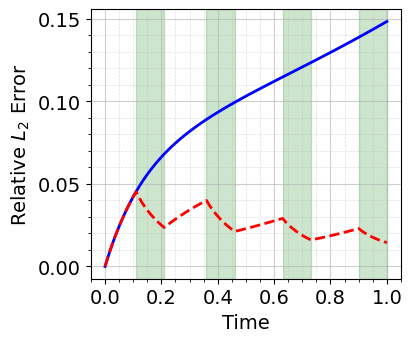

In [ ]:
ts1 = [m[0] * 0.01 for m in mark_coup]
ts2 = [m[-1] * 0.01 for m in mark_coup]

# Plot of L2 error for each time step
l2_error1 = []
l2_error2 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i] - u_test[:,i])/np.linalg.norm(u_test[:,i]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON',lw=2)
plt.plot(t,np.array(l2_error2),color = 'r',linestyle = '--',label = 'ANCHOR', lw = 2)
for x1,x2 in zip(np.array(ts1),np.array(ts2)):
    plt.axvspan(x1,x2,color = 'g',alpha = 0.2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# plt.legend()
plt.savefig(folder+sample_folder+"/coupled_L2_error.pdf",dpi = 300, bbox_inches='tight')
plt.show()

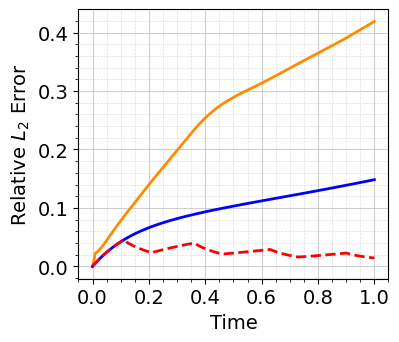

In [ ]:
l2_error1 = []
l2_error2 = []
l2_error3 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i] - u_test[:,i])/np.linalg.norm(u_test[:,i]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))
    l2_error3.append(np.linalg.norm(u_pred_auto[:,i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error3),color = 'darkorange',label = 'AR-DON',lw = 2)
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON', lw = 2)
plt.plot(t,np.array(l2_error2),color = 'r', linestyle = '--',label = 'ANCHOR', lw = 2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
# plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.savefig(folder+sample_folder+"/l2errors.pdf",dpi = 300, bbox_inches='tight')
plt.show()

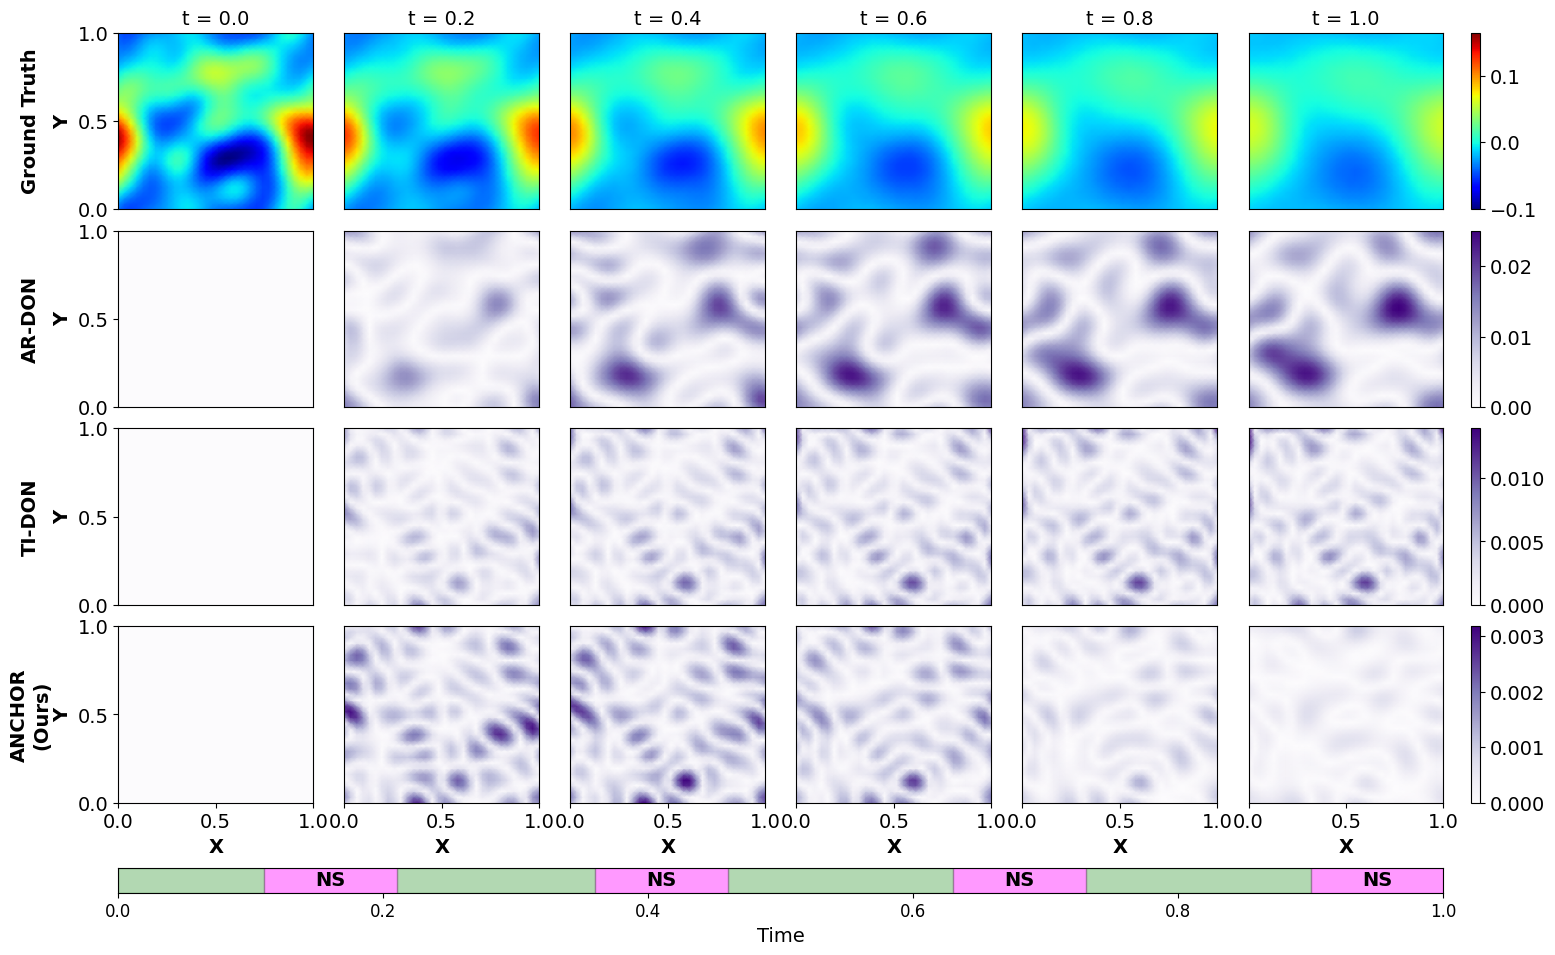

In [ ]:
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

tsteps = [0, 20, 40, 60, 80, 100]

nrow = 4
ncol = len(tsteps)

row_labels = [
    "Ground Truth",
    "AR-DON",
    "TI-DON",
    "ANCHOR\n(Ours)",
]

# Color limits per row
row_clims = {}

# Row 0: Ground truth
row_clims[0] = (
    min(u_test[0][t].min() for t in tsteps),
    max(u_test[0][t].max() for t in tsteps),
)

# Row 1: Autoregressive error
row_clims[1] = (
    min(np.abs(u_pred_auto[0][t] - u_test[0][t]).min() for t in tsteps),
    max(np.abs(u_pred_auto[0][t] - u_test[0][t]).max() for t in tsteps),
)

# Row 2: TIDON error
row_clims[2] = (
    min(np.abs(u_pred_model[t] - u_test[0][t]).min() for t in tsteps),
    max(np.abs(u_pred_model[t] - u_test[0][t]).max() for t in tsteps),
)

# Row 3: TIDON+NS error
row_clims[3] = (
    min(np.abs(u_pred_coup[t] - u_test[0][t]).min() for t in tsteps),
    max(np.abs(u_pred_coup[t] - u_test[0][t]).max() for t in tsteps),
)


fig = plt.figure(figsize=(18, 10))

gs = fig.add_gridspec(
    nrow, ncol,
    hspace=0.12,   
    wspace=0.16   
)

top_row_axes = []

for i in range(nrow):
    row_axes = []
    im = None

    for j in range(ncol):
        idx = i * ncol + j + 1
        ax = fig.add_subplot(gs[i, j])
        
        vmin, vmax = row_clims[i]

        if i == 0:
            im = ax.pcolormesh(
                X, Y, u_test[0][tsteps[j]],
                cmap='jet',
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )

        elif i == 1:
            im = ax.pcolormesh(
                X, Y, np.abs(u_pred_auto[0][tsteps[j]] - u_test[0][tsteps[j]]),
                cmap='Purples',
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )

        elif i == 2:
            im = ax.pcolormesh(
                X, Y, np.abs(u_pred_model[tsteps[j]] - u_test[0][tsteps[j]]),
                cmap='Purples',
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )

        elif i == 3:
            im = ax.pcolormesh(
                X, Y, np.abs(u_pred_coup[tsteps[j]] - u_test[0][tsteps[j]]),
                cmap='Purples',
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )
            ax.set_xlabel("X", fontsize=14,fontweight = 'bold')

        # ax.set_aspect('equal')

        # Row labels (first column)
        if j == 0:
            ax.text(-0.45, 0.5, row_labels[i],
                    transform=ax.transAxes,
                    rotation=90, va='center', ha='center',
                    fontsize=14, fontweight='bold')
            ax.set_ylabel("Y", fontsize=14,fontweight = 'bold')
        else:
            ax.tick_params(left=False, labelleft=False)
        # Column titles (top row)
        if i == 0:
            ax.set_title(f"t = {0.01*tsteps[j]}",fontsize = 14)

        row_axes.append(ax)
        ax.tick_params(axis='both', labelsize=14)
        ax.xaxis.set_major_formatter(
            mticker.FormatStrFormatter('%.1f')
        )
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if i == nrow - 1:
            ax.tick_params(labelbottom=True)
            top_row_axes.append(ax)
            # ax.set_xlabel(xlabel, fontsize=12)
                
        else:
            ax.tick_params(bottom=False, labelbottom=False)

        # if i == nrow-1:
        #     top_row_axes.append(ax)
        

    # Colorbar for the row
    cbar = fig.colorbar(im, ax=row_axes, location='right', pad=0.02, fraction=0.03)
    cbar.ax.tick_params(labelsize=14)


# Add number line 

ax_left = top_row_axes[0]
ax_right = top_row_axes[-1]

pos_left = ax_left.get_position()
pos_right = ax_right.get_position()
numline_height = 0.025
numline_bottom = pos_left.y0 - 0.09  
ax_num = fig.add_axes([pos_left.x0, numline_bottom, pos_right.x1 - pos_left.x0, numline_height])

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_yticks([])

sections = [(s, e) for s, e in zip(ts1, ts2)]

for start, end in sections:
    ax_num.axvspan(start, end, color='magenta', alpha=0.4)
labels = ['NS']*len(ts1)

for (start, end), label in zip(zip(ts1, ts2), labels):
    x_mid = 0.5 * (start + end)
    ax_num.text(
        x_mid, 0.5,         
        label,
        ha="center",
        va="center",
        fontsize=14,
        color="black",
        fontweight="bold"
    )

grey_intervals = []

# Before first red section
if ts1[0] > 0:
    grey_intervals.append((0, ts1[0]))

# Between red sections
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        grey_intervals.append((ts2[i], ts1[i + 1]))

# After last red section
if ts2[-1] < 1:
    grey_intervals.append((ts2[-1], 1))

# Draw grey spans
for start, end in grey_intervals:
    ax_num.axvspan(start, end, color='green', alpha=0.3)
ax_num.set_xlabel("Time", fontsize=14)
ax_num.tick_params(axis='both', labelsize=12)

# plt.tight_layout()
plt.savefig(folder+sample_folder+"/gt_errors.pdf",dpi = 300, bbox_inches='tight')
plt.show()


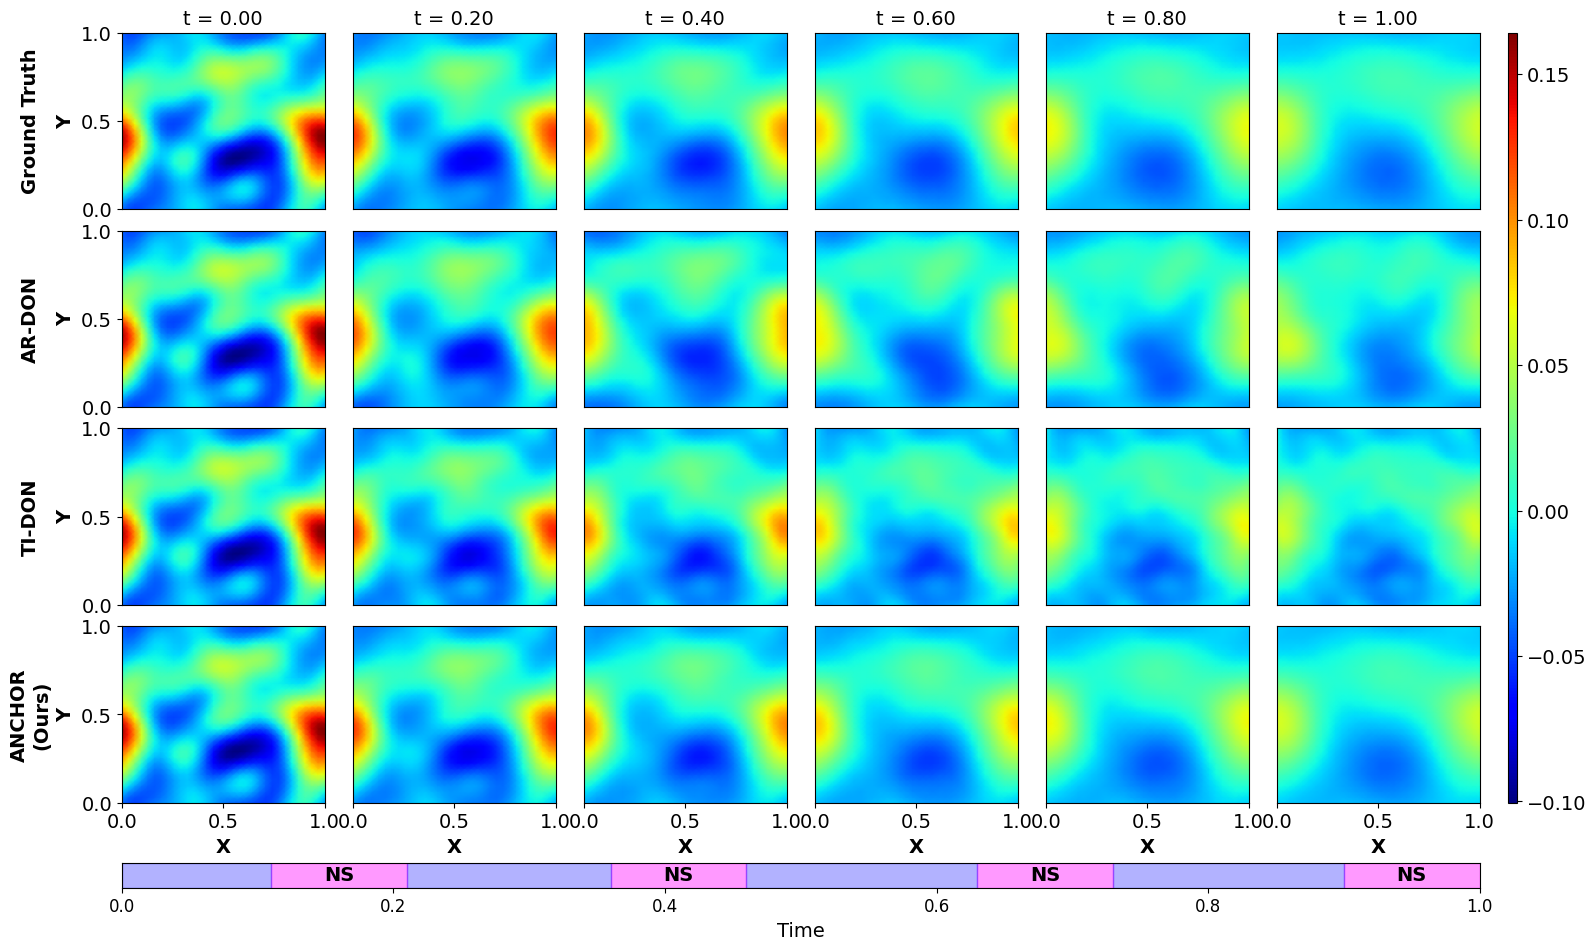

In [ ]:
X, Y = np.meshgrid(x, y)

tsteps = [0, 20, 40, 60, 80, 100]

nrow = 4
ncol = len(tsteps)

row_labels = [
    "Ground Truth",
    "AR-DON",
    "TI-DON",
    "ANCHOR\n(Ours)",
]

global_min = min(
    u_test[0][t].min()
    for t in tsteps
)

global_max = max(
    u_test[0][t].max()
    for t in tsteps
)

fig = plt.figure(figsize=(18, 10))

gs = fig.add_gridspec(
    nrow,
    ncol + 1,                       
    hspace=0.12,
    wspace=0.16,
    width_ratios=[1]*ncol + [0.045]
)

all_axes = []
im_global = None
bottom_row_axes = []

for i in range(nrow):
    for j in range(ncol):
        ax = fig.add_subplot(gs[i, j])
        all_axes.append(ax)

        vmin, vmax = global_min, global_max

        if i == 0:
            data = u_test[0][tsteps[j]]
        elif i == 1:
            data = u_pred_auto[0][tsteps[j]]
        elif i == 2:
            data = u_pred_model[tsteps[j]]
        else:
            data = u_pred_coup[tsteps[j]]

        im = ax.pcolormesh(
            X, Y, data,
            cmap="jet",
            shading="gouraud",
            vmin=vmin,
            vmax=vmax
        )

        im_global = im  # store last handle

        # Row labels (first column only)
        if j == 0:
            ax.text(
                -0.45, 0.5,
                row_labels[i],
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                fontweight="bold"
            )
            ax.set_ylabel("Y", fontsize=14, fontweight="bold")
        else:
            ax.tick_params(left=False, labelleft=False)

        # Column titles (top row)
        if i == 0:
            ax.set_title(f"t = {0.01*tsteps[j]:.2f}", fontsize=14)

        # Axis formatting
        ax.tick_params(axis="both", labelsize=14)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.xaxis.set_major_formatter(
            mticker.FormatStrFormatter("%.1f")
        )

        if i == nrow - 1:
            ax.set_xlabel("X", fontsize=14, fontweight="bold")
            bottom_row_axes.append(ax)
        else:
            ax.tick_params(bottom=False, labelbottom=False)


# Colorbar (spans ALL rows)

cax = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(im_global, cax=cax)
cbar.ax.tick_params(labelsize=14)
# cbar.set_label("Solution value", fontsize=14, fontweight="bold")

# Number Line
pos_left = bottom_row_axes[0].get_position()
pos_right = bottom_row_axes[-1].get_position()

numline_height = 0.025
numline_bottom = pos_left.y0 - 0.085

ax_num = fig.add_axes([
    pos_left.x0,
    numline_bottom,
    pos_right.x1 - pos_left.x0,
    numline_height
])

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_yticks([])

# Red (NS) regions
for s, e in zip(ts1, ts2):
    ax_num.axvspan(s, e, color="magenta", alpha=0.4)
    ax_num.text(
        0.5 * (s + e), 0.5,
        "NS",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

# Blue (non-NS) regions
intervals = []
if ts1[0] > 0:
    intervals.append((0, ts1[0]))
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        intervals.append((ts2[i], ts1[i + 1]))
if ts2[-1] < 1:
    intervals.append((ts2[-1], 1))

for s, e in intervals:
    ax_num.axvspan(s, e, color="b", alpha=0.3)

ax_num.set_xlabel("Time", fontsize=14)
ax_num.tick_params(axis="x", labelsize=12)

# -------------------------------------------------
# SAVE
# -------------------------------------------------
plt.savefig(
    folder + sample_folder + "/solutions.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
